# Probabilistic Archetypal Analysis: application to simulated data

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [2]:
from pypaa import PoissonAA, MultinomialAA, NormalAA, BernoulliAA

## Poisson PAA

In [3]:
# ------------------------------------------ #
# -- simulate Poisson-AA distributed data -- #
# ------------------------------------------ #
n_archetypes_sim = 5
nfeats = 50
nsamples = 1000

# -- simulate archetypal Poisson Lambdas
archetype_lamdas = np.random.uniform(low=0,high=5,size=(n_archetypes_sim,nfeats))
archetype_lamdas[archetype_lamdas<2] = 0


# generate samples distributed around archetypes (set smaller alpha for purer mixtures of archetypes)
sample_lamdas = (np.random.dirichlet(alpha=[0.05]*n_archetypes_sim, size=nsamples) @ archetype_lamdas)

# -- simulate Poisson distributed observed data from these
rng = np.random.default_rng()
X = rng.poisson(lam=sample_lamdas)

# -- remove features that are never used
bool_keep_feats = X.sum(axis=0)>0
X = X[:,bool_keep_feats]
archetype_lamdas = archetype_lamdas[:,bool_keep_feats]
sample_lamdas = sample_lamdas[:,bool_keep_feats]

print('Archetypes shape:      ', archetype_lamdas.shape)
print('Simulated counts shape:', X.shape)

Archetypes shape:       (5, 49)
Simulated counts shape: (1000, 49)


In [4]:
# -- fit Poisson AA model
n_archetypes = 5

aa_params = {
    'niter' : 1000,
    'n_archetypes' : n_archetypes,
}

poisson_aa_model = PoissonAA(**aa_params)

W, H, A, cost_array = poisson_aa_model.fit(X.T)
print(W.shape, H.shape, A.shape)

(49, 1000)
(1000, 5) (5, 1000) (49, 5)


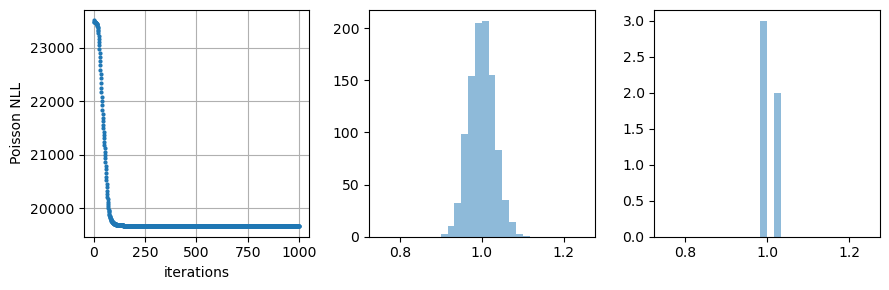

In [5]:
fig, axs = plt.subplots(1,3,figsize=(9,3))
axs = axs.ravel()

axs[0].plot(range(poisson_aa_model.n_iterations+1), cost_array,'o', markersize=2)
axs[0].set_ylabel('Poisson NLL')
axs[0].set_xlabel('iterations')
axs[0].grid()

axs[1].hist(H.sum(axis=0),30,range=(0.75,1.25),alpha=0.5)
axs[2].hist(W.sum(axis=0),30,range=(0.75,1.25),alpha=0.5)

plt.tight_layout()
plt.show()

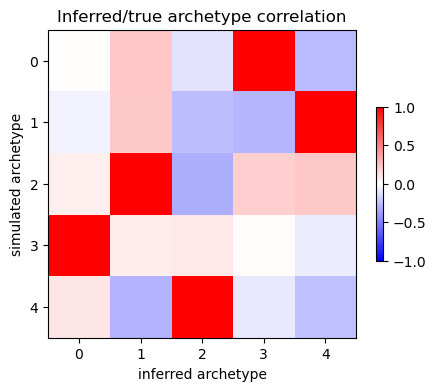

In [6]:
arch_corr = np.corrcoef(archetype_lamdas, poisson_aa_model.A.T)[:n_archetypes_sim][:,n_archetypes_sim:]

fig = plt.figure(figsize=(5,4))

im = plt.imshow(arch_corr, cmap='bwr', vmin=-1, vmax=1)
ax = plt.gca()

fig.colorbar(im, ax = ax, shrink=0.5)

plt.title('Inferred/true archetype correlation')
plt.xlabel('inferred archetype')
plt.ylabel('simulated archetype')

plt.show()

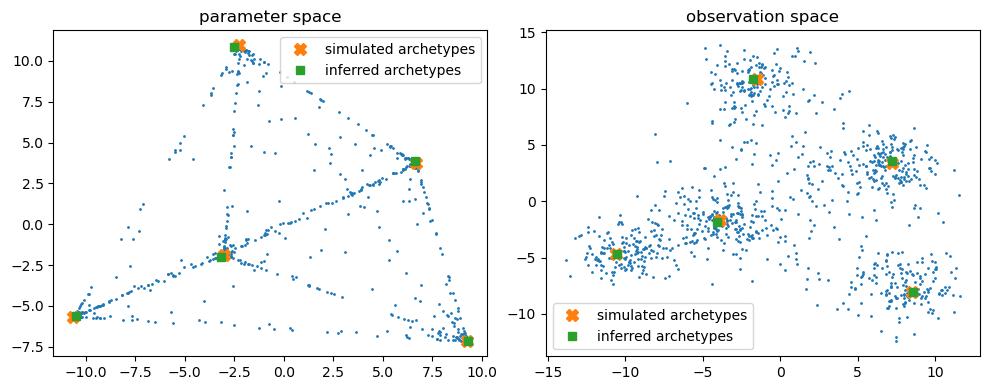

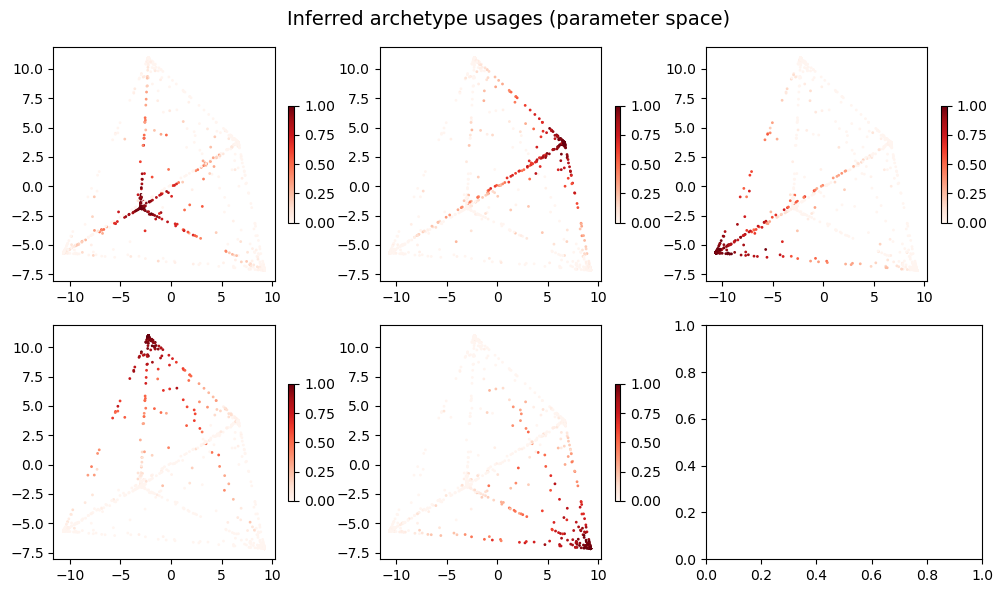

In [7]:
# plot in parameter space
pca_model = PCA(n_components=3)
pca_model.fit(archetype_lamdas)

X_pca = pca_model.transform(sample_lamdas)
arch_pca = pca_model.transform(archetype_lamdas)
inferred_arch_pca = pca_model.transform(A.T)

pca_model2 = PCA(n_components=3)
pca_model2.fit(X)

X_pca2             = pca_model2.transform(X)
arch_pca2          = pca_model2.transform(archetype_lamdas)
inferred_arch_pca2 = pca_model2.transform(A.T)

# -- plot of simulated data & archetypes
fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

# -- plot in parameter space
axs[0].plot(X_pca[:,0], X_pca[:,1],'o', markersize=1)
axs[0].plot(arch_pca[:,0], arch_pca[:,1],'X', markersize=8,label='simulated archetypes')
axs[0].plot(inferred_arch_pca[:,0], inferred_arch_pca[:,1],'s', markersize=6,label='inferred archetypes')
axs[0].legend()
axs[0].set_title('parameter space')

# -- plot in observation space
axs[1].plot(X_pca2[:,0], X_pca2[:,1],'o', markersize=1)
axs[1].plot(arch_pca2[:,0], arch_pca2[:,1],'X', markersize=8,label='simulated archetypes')
axs[1].plot(inferred_arch_pca2[:,0], inferred_arch_pca2[:,1],'s', markersize=6,label='inferred archetypes')
axs[1].legend()
axs[1].set_title('observation space')

plt.tight_layout()
plt.show()


# -- plot usages
fig, axs = plt.subplots(2,3, figsize=(10,6))
axs = axs.ravel()

for i in range(poisson_aa_model.n_archetypes):

    ax = axs[i]
    tmp_plt = axs[i].scatter(X_pca[:,0], X_pca[:,1],s=1,c=H.T[:,i],
                             cmap='Reds',vmin=0, vmax=1)

    fig.colorbar(tmp_plt, ax=ax, shrink=0.5)

fig.suptitle('Inferred archetype usages (parameter space)', fontsize=14)

plt.tight_layout()
plt.show()

## Multinomial PAA

In [8]:
# ---------------------------------------------- #
# -- simulate Multinomial-AA distributed data -- #
# ---------------------------------------------- #

n_archetypes_sim = 5
nfeats = 70
nsamples = 1000

# -- archetype probability distributions (~ topics in topic modelling)
archetypes_sim = np.random.randint(low=0,high=50,size=(n_archetypes_sim,nfeats))
archetypes_sim[archetypes_sim<25] = 0

# -- remove features never used
archetypes_sim = archetypes_sim[:,archetypes_sim.sum(axis=0)>0]
archetypes_sim = normalize(archetypes_sim, norm='l1', axis=1)

# -- generate sample archetypes (these will be parameters of multinomial)
sample_ps = (np.random.dirichlet(alpha=[0.05]*n_archetypes_sim, size=nsamples)) @ archetypes_sim

# -- generate sample n_occurences (~ document lengths in NLP)
sample_n_occurences = np.random.randint(low=1000, high=2000, size=nsamples)

print(sample_ps.shape, sample_n_occurences.shape)

# -- sample from multinomial
rng = np.random.default_rng()
X = rng.multinomial(sample_n_occurences, sample_ps, size=nsamples)

print('Archetypes shape:      ', archetypes_sim.shape)
print('Simulated counts shape:', X.shape)

(1000, 69) (1000,)
Archetypes shape:       (5, 69)
Simulated counts shape: (1000, 69)


In [9]:
# -- fit Multinomial AA model
aa_params = {
    'niter' : 250,
    'n_archetypes' : 5,
}

multinomial_aa_model = MultinomialAA(**aa_params)

W, H, A, cost_array = multinomial_aa_model.fit(X.T)
print(W.shape, H.shape, A.shape)

(1000, 5) (5, 1000) (69, 5)


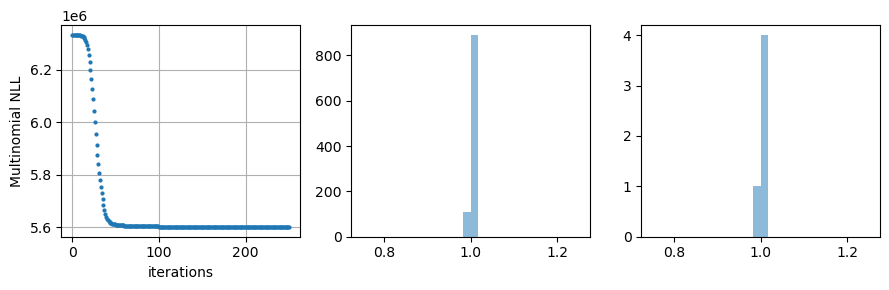

In [10]:
fig, axs = plt.subplots(1,3,figsize=(9,3))
axs = axs.ravel()

axs[0].plot(range(multinomial_aa_model.n_iterations+1), cost_array,'o', markersize=2)
axs[0].set_ylabel('Multinomial NLL')
axs[0].set_xlabel('iterations')
axs[0].grid()

axs[1].hist(H.sum(axis=0),30,range=(0.75,1.25),alpha=0.5)
axs[2].hist(W.sum(axis=0),30,range=(0.75,1.25),alpha=0.5)

plt.tight_layout()
plt.show()

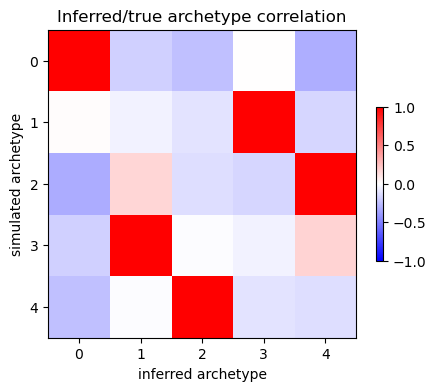

In [11]:
arch_corr = np.corrcoef(archetypes_sim, multinomial_aa_model.A.T)[:n_archetypes_sim][:,n_archetypes_sim:]

fig = plt.figure(figsize=(5,4))

im = plt.imshow(arch_corr, cmap='bwr', vmin=-1, vmax=1)
ax = plt.gca()

fig.colorbar(im, ax = ax, shrink=0.5)

plt.title('Inferred/true archetype correlation')
plt.xlabel('inferred archetype')
plt.ylabel('simulated archetype')

plt.show()

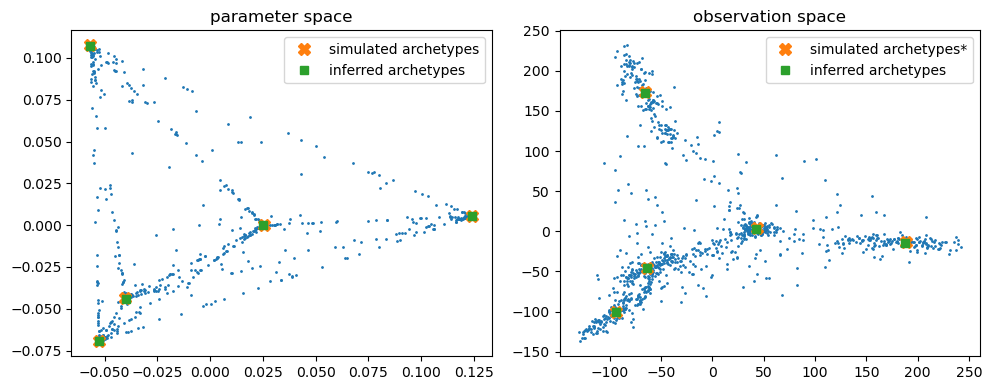

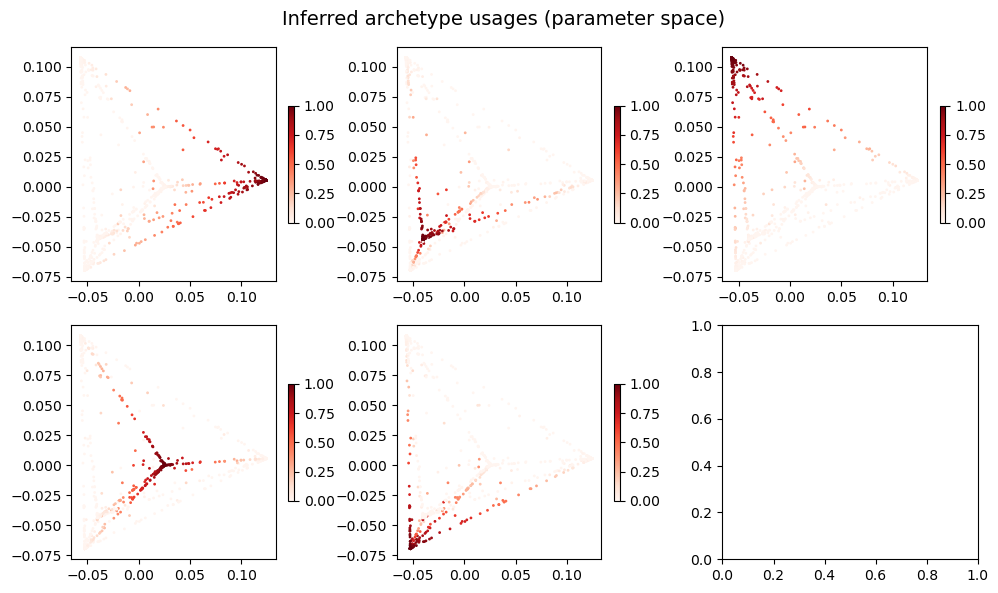

In [12]:
# plot in parameter space
pca_model = PCA(n_components=3)
pca_model.fit(archetypes_sim)

X_pca = pca_model.transform(sample_ps)
arch_pca = pca_model.transform(archetypes_sim)
inferred_arch_pca = pca_model.transform(A.T)

pca_model2 = PCA(n_components=3)
pca_model2.fit(X)

X_pca2             = pca_model2.transform(X)
# to get to observation space, we multiply archetypes by the mean of sample occurences
arch_pca2          = pca_model2.transform(archetypes_sim * sample_n_occurences.mean())
inferred_arch_pca2 = pca_model2.transform(A.T * sample_n_occurences.mean())

# -- plot of simulated data & archetypes
fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

# -- plot in parameter space
axs[0].plot(X_pca[:,0], X_pca[:,1],'o', markersize=1)
axs[0].plot(arch_pca[:,0], arch_pca[:,1],'X', markersize=8,label='simulated archetypes')
axs[0].plot(inferred_arch_pca[:,0], inferred_arch_pca[:,1],'s', markersize=6,label='inferred archetypes')
axs[0].legend()
axs[0].set_title('parameter space')

# -- plot in observation space
axs[1].plot(X_pca2[:,0], X_pca2[:,1],'o', markersize=1)
axs[1].plot(arch_pca2[:,0], arch_pca2[:,1],'X', markersize=8,label='simulated archetypes*')
axs[1].plot(inferred_arch_pca2[:,0], inferred_arch_pca2[:,1],'s', markersize=6,label='inferred archetypes')
axs[1].legend()
axs[1].set_title('observation space')

plt.tight_layout()
plt.show()


# -- plot usages
fig, axs = plt.subplots(2,3, figsize=(10,6))
axs = axs.ravel()

for i in range(multinomial_aa_model.n_archetypes):

    ax = axs[i]
    tmp_plt = axs[i].scatter(X_pca[:,0], X_pca[:,1],s=1,c=H.T[:,i],
                             cmap='Reds',vmin=0, vmax=1)

    fig.colorbar(tmp_plt, ax=ax, shrink=0.5)

fig.suptitle('Inferred archetype usages (parameter space)', fontsize=14)

plt.tight_layout()
plt.show()

# Normal AA

In [13]:
# ------------------------------------------- #
# -- simulate Gaussian-AA distributed data -- #
# ------------------------------------------- #

n_archetypes_sim = 5
nfeats = 150
nsamples = 2000

# -- archetypes 
archetypes_sim = np.random.randint(low=0,high=50,size=(n_archetypes_sim,nfeats))
archetypes_sim[archetypes_sim<35] = 0

# -- generate sample archetypes
sample_ps = (np.random.dirichlet(alpha=[0.2]*n_archetypes_sim, size=nsamples)) @ archetypes_sim

# -- sample from normal
rng = np.random.default_rng()
X = rng.normal(sample_ps, scale=2.0)

print('Archetypes shape:      ', archetypes_sim.shape)
print('Simulated counts shape:', X.shape)

Archetypes shape:       (5, 150)
Simulated counts shape: (2000, 150)


In [14]:
# -- fit Normal AA model
aa_params = {
    'niter' : 250,
    'n_archetypes' : 5,
}

normal_aa_model = NormalAA(**aa_params)

W, H, A, cost_array = normal_aa_model.fit(X.T)
print(W.shape, H.shape, A.shape)

(2000, 5) (5, 2000) (150, 5)


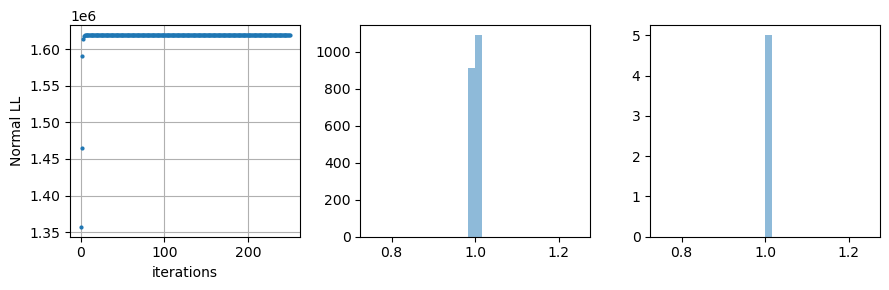

In [15]:
fig, axs = plt.subplots(1,3,figsize=(9,3))
axs = axs.ravel()

axs[0].plot(range(normal_aa_model.n_iterations+1), cost_array,'o', markersize=2)
axs[0].set_ylabel('Normal LL')
axs[0].set_xlabel('iterations')
axs[0].grid()

axs[1].hist(H.sum(axis=0),30,range=(0.75,1.25),alpha=0.5)
axs[2].hist(W.sum(axis=0),30,range=(0.75,1.25),alpha=0.5)

plt.tight_layout()
plt.show()

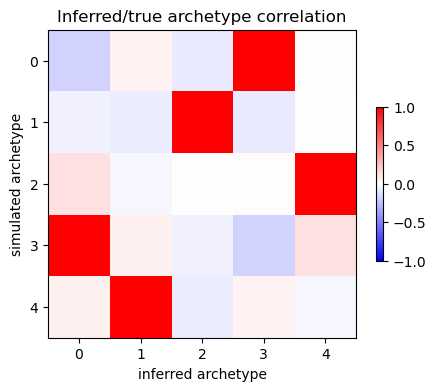

In [17]:
arch_corr = np.corrcoef(archetypes_sim, normal_aa_model.A.T)[:n_archetypes_sim][:,n_archetypes_sim:]

fig = plt.figure(figsize=(5,4))

im = plt.imshow(arch_corr, cmap='bwr', vmin=-1, vmax=1)
ax = plt.gca()

fig.colorbar(im, ax = ax, shrink=0.5)

plt.title('Inferred/true archetype correlation')
plt.xlabel('inferred archetype')
plt.ylabel('simulated archetype')

plt.show()

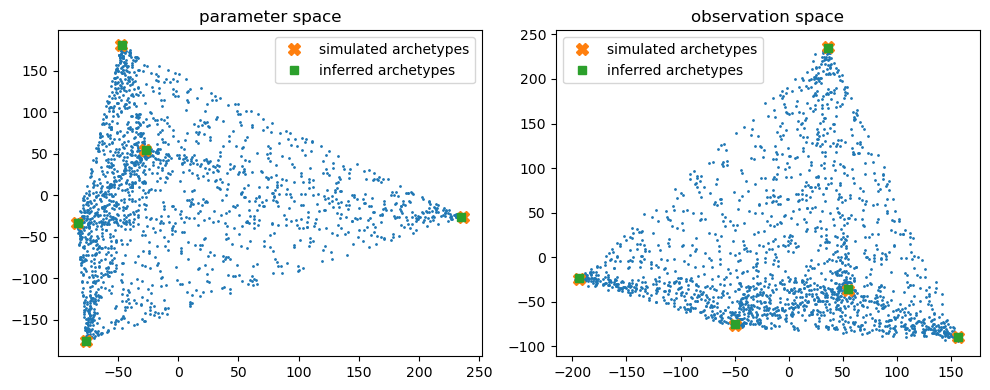

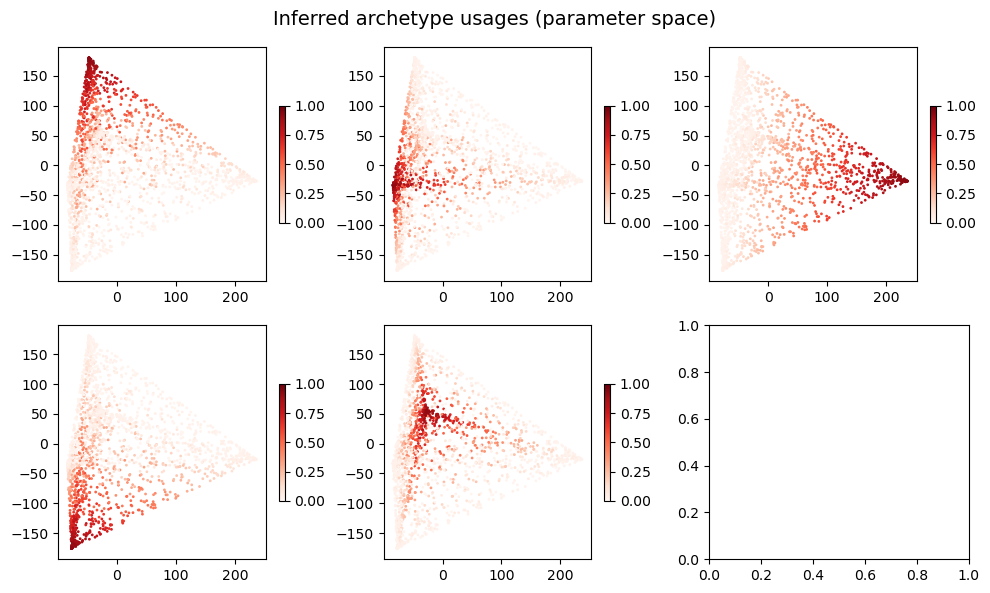

In [18]:
# plot in parameter space
pca_model = PCA(n_components=3)
pca_model.fit(archetypes_sim)

X_pca = pca_model.transform(sample_ps)
arch_pca = pca_model.transform(archetypes_sim)
inferred_arch_pca = pca_model.transform(A.T)

pca_model2 = PCA(n_components=3)
pca_model2.fit(X)

X_pca2             = pca_model2.transform(X)
arch_pca2          = pca_model2.transform(archetypes_sim)
inferred_arch_pca2 = pca_model2.transform(A.T)

# -- plot of simulated data & archetypes
fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

# -- plot in parameter space
axs[0].plot(X_pca[:,0], X_pca[:,1],'o', markersize=1)
axs[0].plot(arch_pca[:,0], arch_pca[:,1],'X', markersize=8,label='simulated archetypes')
axs[0].plot(inferred_arch_pca[:,0], inferred_arch_pca[:,1],'s', markersize=6,label='inferred archetypes')
axs[0].legend()
axs[0].set_title('parameter space')

# -- plot in observation space
axs[1].plot(X_pca2[:,0], X_pca2[:,1],'o', markersize=1)
axs[1].plot(arch_pca2[:,0], arch_pca2[:,1],'X', markersize=8,label='simulated archetypes')
axs[1].plot(inferred_arch_pca2[:,0], inferred_arch_pca2[:,1],'s', markersize=6,label='inferred archetypes')
axs[1].legend()
axs[1].set_title('observation space')

plt.tight_layout()
plt.show()


# -- plot usages
fig, axs = plt.subplots(2,3, figsize=(10,6))
axs = axs.ravel()

for i in range(normal_aa_model.n_archetypes):

    ax = axs[i]
    tmp_plt = axs[i].scatter(X_pca[:,0], X_pca[:,1],s=1,c=H.T[:,i],
                             cmap='Reds',vmin=0, vmax=1)

    fig.colorbar(tmp_plt, ax=ax, shrink=0.5)

fig.suptitle('Inferred archetype usages (parameter space)', fontsize=14)

plt.tight_layout()
plt.show()